In [28]:
!pip3 install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [30]:
processed_data_path = '../data/processed/cleaned_club_loan_two.csv'

# Fallback for different execution environments (root vs notebooks folder)
if not os.path.exists(processed_data_path):
    processed_data_path = '../data/processed/cleaned_club_loan_two.csv'
  

df = pd.read_csv(processed_data_path)
df_copy = df.copy()
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (389412, 32)


Loan Burden Analysis

<Axes: xlabel='loan_repayment_status', ylabel='loan_income_ratio'>

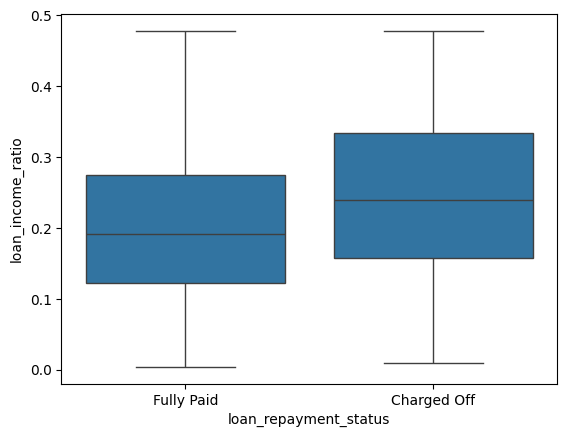

In [31]:
#Remove extreme values using percentile
df_filtered = df[df['loan_income_ratio'] < df['loan_income_ratio'].quantile(0.99)]

sns.boxplot(x='loan_repayment_status', y='loan_income_ratio', data=df_filtered)

Income Segmentation

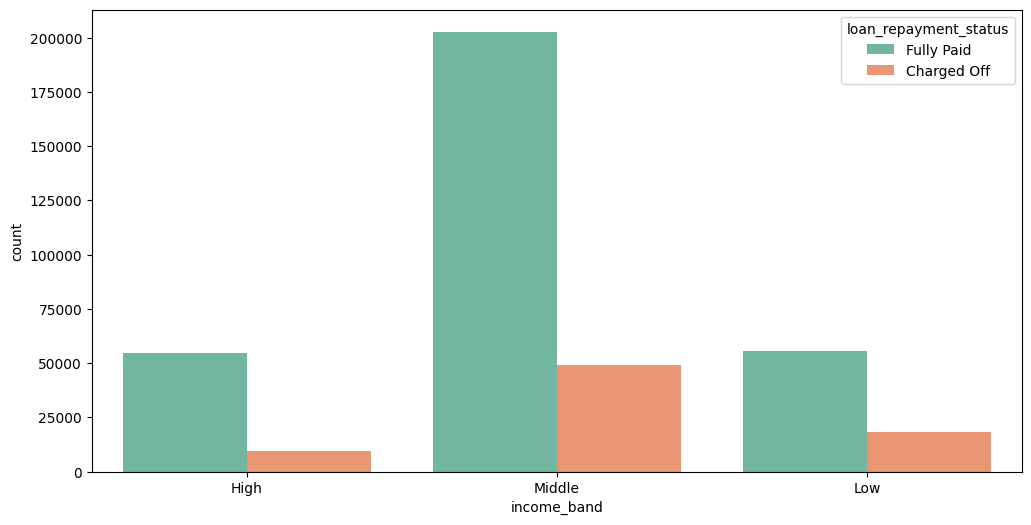

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='income_band',
    hue='loan_repayment_status',
    data=df,             
    palette='Set2'
)

plt.show()

DTI vs. Default Probability

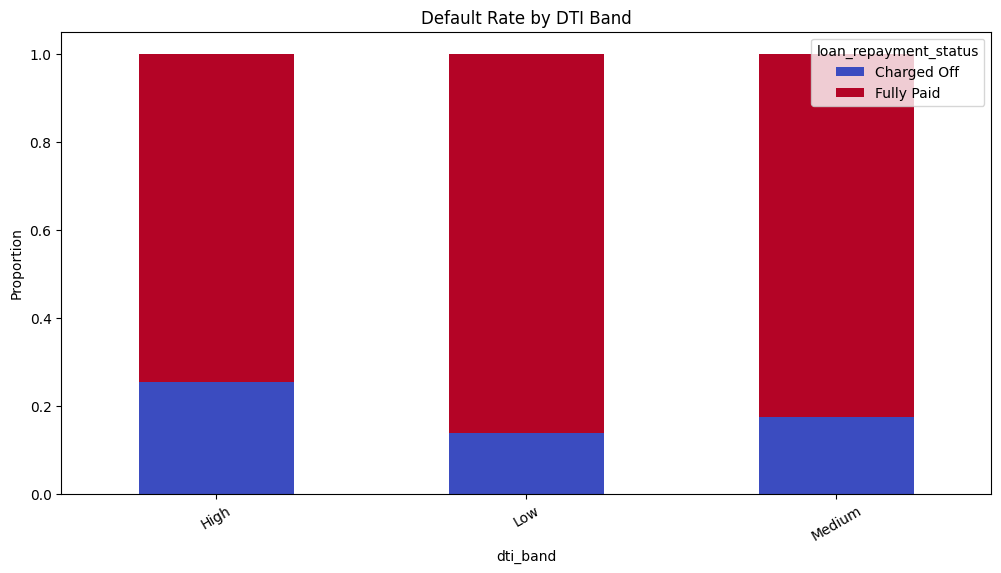

In [17]:
pd.crosstab(df['dti_band'], df['loan_repayment_status'], normalize='index') \
    .plot(kind='bar', stacked=True, figsize=(12,6), colormap='coolwarm')

plt.title('Default Rate by DTI Band')
plt.ylabel('Proportion')
plt.xticks(rotation=30)
plt.show()

/var/folders/5w/q221yrhd6c99fl93ycz7_nk80000gn/T/ipykernel_15535/3866016129.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


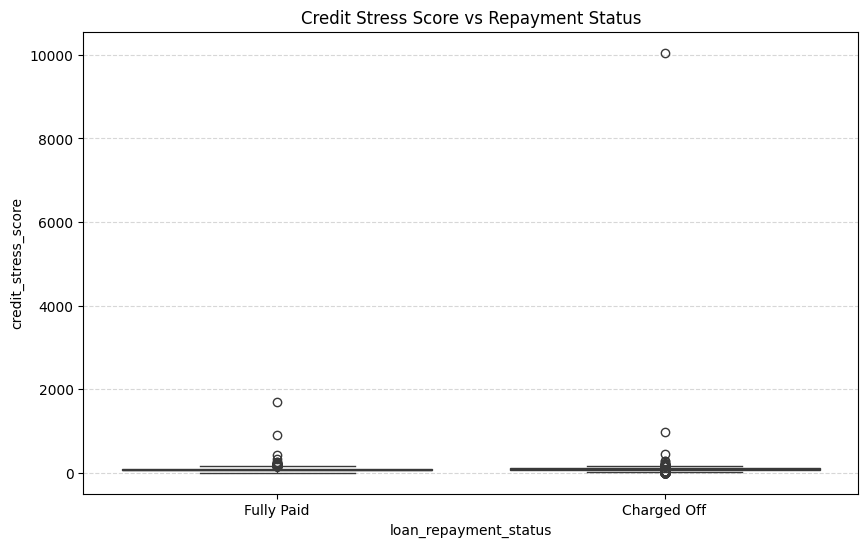

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='loan_repayment_status',
    y='credit_stress_score',
    data=df,
    palette='viridis'
)
plt.title('Credit Stress Score vs Repayment Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

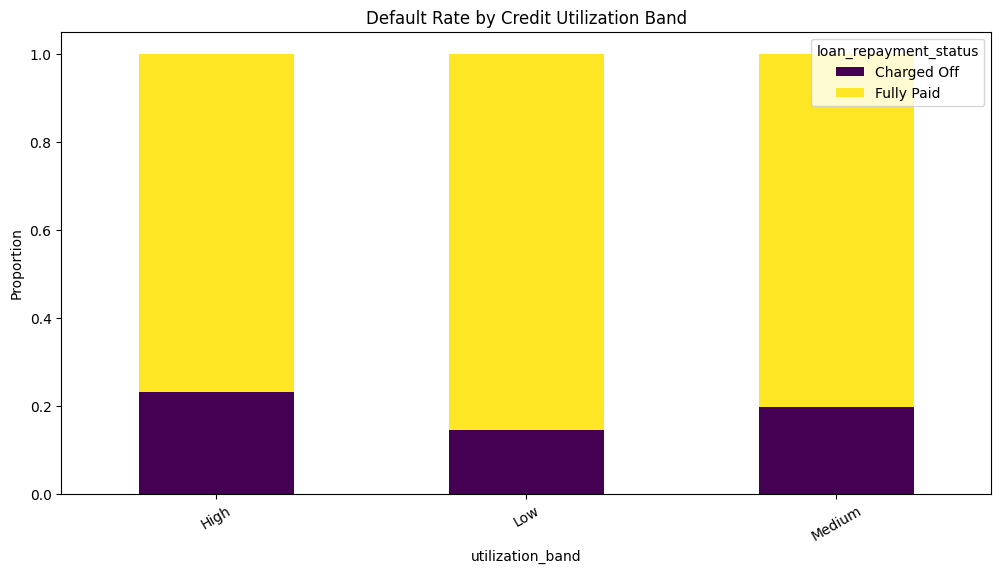

In [22]:
pd.crosstab(df['utilization_band'], df['loan_repayment_status'], normalize='index') \
    .plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')

plt.title('Default Rate by Credit Utilization Band')
plt.ylabel('Proportion')
plt.xticks(rotation=30)
plt.show()

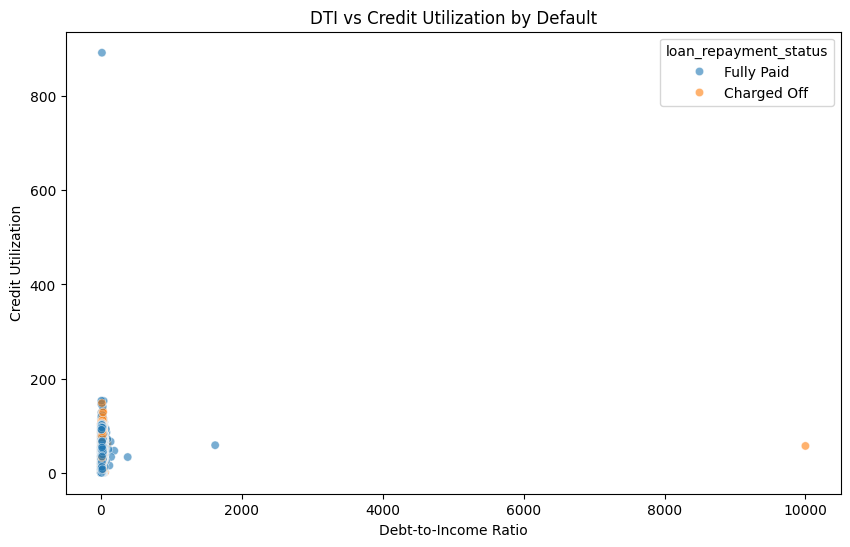

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='debt_to_income_ratio',
    y='revolving_line_utilization',
    hue='loan_repayment_status',
    data=df,
    alpha=0.6
)
plt.title('DTI vs Credit Utilization by Default')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Credit Utilization')
plt.show()

Risk Score Distribution

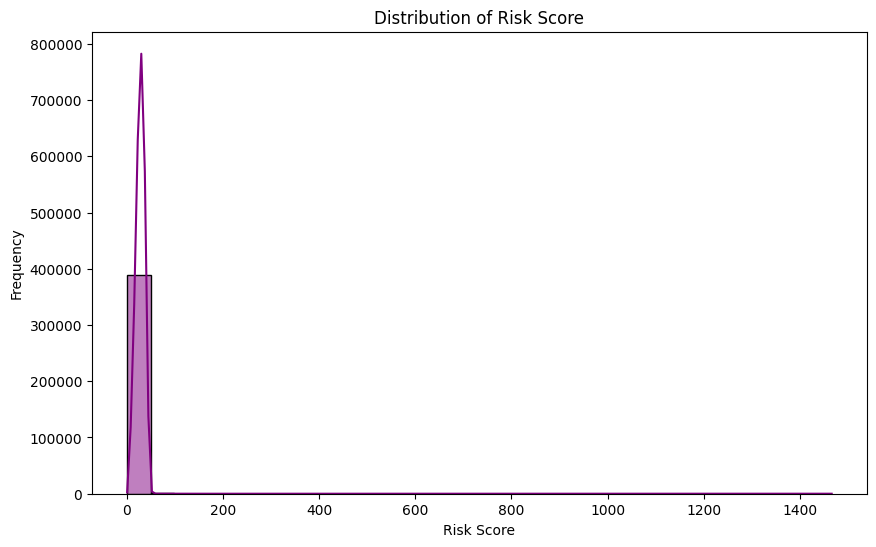

In [27]:
plt.figure(figsize=(10,6))
sns.histplot(df['risk_score'], kde=True, bins=30, color='purple')
plt.title('Distribution of Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.show()

/var/folders/5w/q221yrhd6c99fl93ycz7_nk80000gn/T/ipykernel_15535/2582053391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


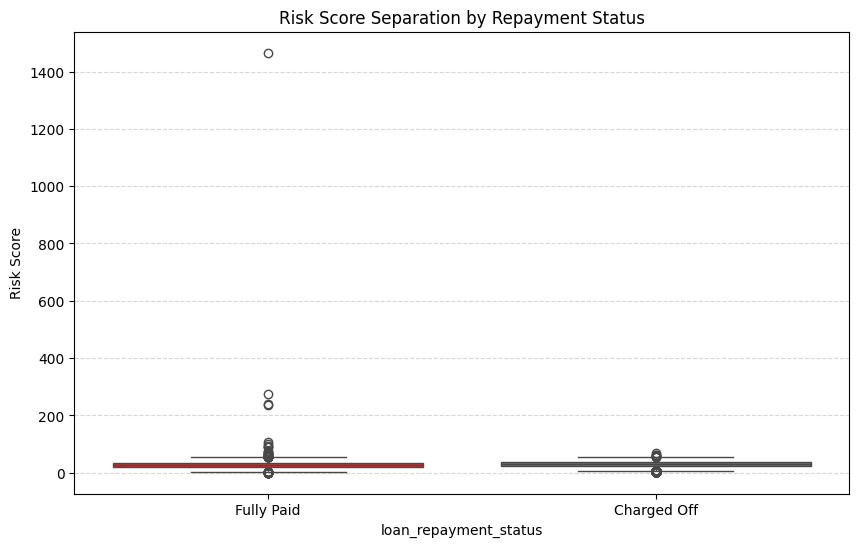

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='loan_repayment_status',
    y='risk_score',
    data=df,
    palette='Set1'
)
plt.title('Risk Score Separation by Repayment Status')
plt.ylabel('Risk Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()